## **Capability-Aware Residual Routing (CARR) — Proof of Concept**
---
**Research Question:** *Can expert-internal signals improve MoE routing beyond external router logits at fixed compute?*

This notebook implements a minimal MoE sandbox and the CARR method across 4 blocks:
1. **Block 1** — Baseline Top-2 MoE Transformer block
2. **Block 2** — Lightweight capability score via frozen probe
3. **Block 3** — Residual fusion of router logits + capability scores
4. **Block 4** — Overfit on tiny text & visualize routing changes

In [1]:
# ── Imports & Setup ──────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import math
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## BLOCK 1 — The Minimal MoE Sandbox

In [2]:
# ── Hyperparameters ──────────────────────────────────────────
EMBED_DIM   = 128        # token embedding dimension
NUM_HEADS   = 4          # attention heads
NUM_EXPERTS = 8          # number of MLP experts
TOP_K       = 2          # top-k routing
FFN_DIM     = 256        # expert hidden dimension
DROPOUT     = 0.1
VOCAB_SIZE  = 5000       # small vocabulary
SEQ_LEN     = 64         # sequence length
BATCH_SIZE  = 8

In [3]:
# ── Expert MLP ───────────────────────────────────────────────
class ExpertMLP(nn.Module):
    """A single feed-forward expert: Linear → GELU → Linear."""
    def __init__(self, embed_dim, ffn_dim, dropout=0.1):
        super().__init__()
        self.w1 = nn.Linear(embed_dim, ffn_dim)
        self.w2 = nn.Linear(ffn_dim, embed_dim)
        self.act = nn.GELU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.w2(self.act(self.w1(x))))

In [4]:
# ── Standard Top-K Router ─────────────────────────────────────
class TopKRouter(nn.Module):
    """Standard external linear router producing per-expert logits."""
    def __init__(self, embed_dim, num_experts, top_k=2):
        super().__init__()
        self.top_k = top_k
        self.gate = nn.Linear(embed_dim, num_experts, bias=False)

    def forward(self, x):
        # x: [B, S, D] → logits: [B, S, E]
        logits = self.gate(x)
        top_k_vals, top_k_indices = torch.topk(logits, self.top_k, dim=-1)
        top_k_gates = F.softmax(top_k_vals, dim=-1)
        return logits, top_k_gates, top_k_indices

In [5]:
# ── Baseline MoE Layer ────────────────────────────────────────
class MoELayer(nn.Module):
    """Mixture-of-Experts FFN with standard Top-K routing."""
    def __init__(self, embed_dim, ffn_dim, num_experts, top_k=2, dropout=0.1):
        super().__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        self.experts = nn.ModuleList([
            ExpertMLP(embed_dim, ffn_dim, dropout) for _ in range(num_experts)
        ])
        self.router = TopKRouter(embed_dim, num_experts, top_k)

    def forward(self, x, return_routing=False):
        B, S, D = x.shape
        logits, gates, indices = self.router(x)  # gates/indices: [B,S,K]

        # Dispatch: for each token, combine top-k expert outputs
        output = torch.zeros_like(x)
        expert_counts = torch.zeros(self.num_experts, device=x.device)

        for k in range(self.top_k):
            expert_idx = indices[:, :, k]   # [B, S]
            gate_val   = gates[:, :, k]     # [B, S]
            for e in range(self.num_experts):
                mask = (expert_idx == e)    # [B, S]
                if mask.any():
                    expert_counts[e] += mask.sum().item()
                    tokens = x[mask]        # [N, D]
                    expert_out = self.experts[e](tokens)
                    output[mask] += gate_val[mask].unsqueeze(-1) * expert_out

        if return_routing:
            return output, logits, gates, indices, expert_counts
        return output

In [6]:
# ── Multi-Head Self-Attention ──────────────────────────────────
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads,
                                          dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Causal mask for autoregressive LM
        S = x.size(1)
        mask = torch.triu(torch.ones(S, S, device=x.device), diagonal=1).bool()
        attn_out, _ = self.attn(x, x, x, attn_mask=mask)
        return self.norm(x + self.dropout(attn_out))

In [7]:
# ── Transformer Block with MoE FFN ────────────────────────────
class TransformerMoEBlock(nn.Module):
    """Single Transformer block: Self-Attention → MoE FFN."""
    def __init__(self, embed_dim, num_heads, ffn_dim, num_experts,
                 top_k=2, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.moe = MoELayer(embed_dim, ffn_dim, num_experts, top_k, dropout)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x, return_routing=False):
        x = self.attn(x)
        if return_routing:
            moe_out, logits, gates, indices, counts = self.moe(x, return_routing=True)
            return self.norm(x + moe_out), logits, gates, indices, counts
        return self.norm(x + self.moe(x))

In [8]:
# ── Tiny Transformer LM ───────────────────────────────────────
class TinyMoELM(nn.Module):
    """Minimal autoregressive LM with one MoE Transformer block."""
    def __init__(self, vocab_size, embed_dim, num_heads, ffn_dim,
                 num_experts, top_k=2, dropout=0.1):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb = nn.Embedding(512, embed_dim)  # max 512 positions
        self.block = TransformerMoEBlock(embed_dim, num_heads, ffn_dim,
                                         num_experts, top_k, dropout)
        self.head = nn.Linear(embed_dim, vocab_size)
        self.embed_dim = embed_dim

    def forward(self, input_ids, return_routing=False):
        B, S = input_ids.shape
        pos = torch.arange(S, device=input_ids.device).unsqueeze(0)
        x = self.tok_emb(input_ids) + self.pos_emb(pos)
        if return_routing:
            x, logits, gates, indices, counts = self.block(x, return_routing=True)
            return self.head(x), logits, gates, indices, counts
        return self.head(x)

In [9]:
# ── Baseline Smoke Test ───────────────────────────────────────
model_baseline = TinyMoELM(
    VOCAB_SIZE, EMBED_DIM, NUM_HEADS, FFN_DIM, NUM_EXPERTS, TOP_K, DROPOUT
).to(device)

dummy_ids = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE, SEQ_LEN), device=device)
out = model_baseline(dummy_ids)
print(f"✅ Block 1 smoke test passed!")
print(f"   Input shape:  {dummy_ids.shape}")
print(f"   Output shape: {out.shape}")
print(f"   Num params:   {sum(p.numel() for p in model_baseline.parameters()):,}")

✅ Block 1 smoke test passed!
   Input shape:  torch.Size([8, 64])
   Output shape: torch.Size([8, 64, 5000])
   Num params:   1,945,480


## BLOCK 2 — The Lightweight Capability Score

In [10]:
# ── Capability Probe ──────────────────────────────────────────
class CapabilityProbe(nn.Module):
    """
    Extracts c_e(x) = ||W_probe @ x||_2 for each expert.
    
    W_probe is a frozen slice of each expert's first linear layer.
    This avoids the full expert forward pass while capturing what
    the expert's input projection "cares about."
    """
    def __init__(self, experts: nn.ModuleList, probe_dim=32):
        super().__init__()
        self.num_experts = len(experts)
        self.probe_dim = probe_dim
        
        # Slice the first `probe_dim` rows from each expert's w1
        # and freeze them — these are our "routing neurons"
        probes = []
        for expert in experts:
            W = expert.w1.weight.data[:probe_dim, :]  # [probe_dim, embed_dim]
            probes.append(W.clone())
        
        # Stack into [num_experts, probe_dim, embed_dim] — FROZEN
        self.register_buffer("W_probe", torch.stack(probes, dim=0))
    
    def forward(self, x):
        """
        Args:
            x: [B, S, D]
        Returns:
            capability_scores: [B, S, num_experts]
        """
        B, S, D = x.shape
        # W_probe: [E, P, D]   x: [B, S, D]
        # Project: [B, S, E, P] via einsum
        projections = torch.einsum("epd, bsd -> bsep", self.W_probe, x)
        # L2 norm along probe dimension → [B, S, E]
        capability_scores = torch.norm(projections, p=2, dim=-1)
        return capability_scores

In [11]:
# ── Capability Score Shape Test ────────────────────────────────
probe = CapabilityProbe(model_baseline.block.moe.experts, probe_dim=32).to(device)
dummy_x = torch.randn(BATCH_SIZE, SEQ_LEN, EMBED_DIM, device=device)
c_scores = probe(dummy_x)
print(f"✅ Block 2 shape test passed!")
print(f"   Input shape:         {dummy_x.shape}")
print(f"   Capability scores:   {c_scores.shape}")
print(f"   Expected:            [B={BATCH_SIZE}, S={SEQ_LEN}, E={NUM_EXPERTS}]")
print(f"   Score range:         [{c_scores.min():.3f}, {c_scores.max():.3f}]")

✅ Block 2 shape test passed!
   Input shape:         torch.Size([8, 64, 128])
   Capability scores:   torch.Size([8, 64, 8])
   Expected:            [B=8, S=64, E=8]
   Score range:         [1.969, 5.000]


## BLOCK 3 — Residual Fusion (CARR)

In [12]:
# ── CARR Router ───────────────────────────────────────────────
class CARRRouter(nn.Module):
    """
    Capability-Aware Residual Router.
    
    s_e = normalize(r_e) + λ · normalize(c_e(x))
    
    where r_e are standard router logits and c_e(x) is the
    frozen-probe capability score.
    """
    def __init__(self, embed_dim, num_experts, experts, top_k=2,
                 lambd=0.5, probe_dim=32):
        super().__init__()
        self.top_k = top_k
        self.lambd = lambd
        self.gate = nn.Linear(embed_dim, num_experts, bias=False)
        self.probe = CapabilityProbe(experts, probe_dim)
        self.norm_r = nn.LayerNorm(num_experts)
        self.norm_c = nn.LayerNorm(num_experts)

    def forward(self, x):
        """
        Args:
            x: [B, S, D]
        Returns:
            fused_logits, top_k_gates, top_k_indices
        """
        r = self.gate(x)                          # [B, S, E]
        c = self.probe(x)                         # [B, S, E]
        
        # Normalize to same scale before fusion
        r_norm = self.norm_r(r)
        c_norm = self.norm_c(c)
        
        # CARR fusion
        s = r_norm + self.lambd * c_norm           # [B, S, E]
        
        top_k_vals, top_k_indices = torch.topk(s, self.top_k, dim=-1)
        top_k_gates = F.softmax(top_k_vals, dim=-1)
        return s, top_k_gates, top_k_indices

In [13]:
# ── CARR MoE Layer ─────────────────────────────────────────────
class CARRMoELayer(nn.Module):
    """MoE FFN with CARR routing."""
    def __init__(self, embed_dim, ffn_dim, num_experts, top_k=2,
                 dropout=0.1, lambd=0.5, probe_dim=32):
        super().__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        self.experts = nn.ModuleList([
            ExpertMLP(embed_dim, ffn_dim, dropout) for _ in range(num_experts)
        ])
        self.router = CARRRouter(embed_dim, num_experts, self.experts,
                                  top_k, lambd, probe_dim)

    def forward(self, x, return_routing=False):
        B, S, D = x.shape
        logits, gates, indices = self.router(x)

        output = torch.zeros_like(x)
        expert_counts = torch.zeros(self.num_experts, device=x.device)

        for k in range(self.top_k):
            expert_idx = indices[:, :, k]
            gate_val   = gates[:, :, k]
            for e in range(self.num_experts):
                mask = (expert_idx == e)
                if mask.any():
                    expert_counts[e] += mask.sum().item()
                    tokens = x[mask]
                    expert_out = self.experts[e](tokens)
                    output[mask] += gate_val[mask].unsqueeze(-1) * expert_out

        if return_routing:
            return output, logits, gates, indices, expert_counts
        return output

In [14]:
# ── CARR Transformer Block + LM ────────────────────────────────
class CARRTransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ffn_dim, num_experts,
                 top_k=2, dropout=0.1, lambd=0.5, probe_dim=32):
        super().__init__()
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.moe = CARRMoELayer(embed_dim, ffn_dim, num_experts,
                                 top_k, dropout, lambd, probe_dim)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x, return_routing=False):
        x = self.attn(x)
        if return_routing:
            moe_out, logits, gates, indices, counts = self.moe(x, True)
            return self.norm(x + moe_out), logits, gates, indices, counts
        return self.norm(x + self.moe(x))


class CARRMoELM(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ffn_dim,
                 num_experts, top_k=2, dropout=0.1, lambd=0.5, probe_dim=32):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb = nn.Embedding(512, embed_dim)
        self.block = CARRTransformerBlock(embed_dim, num_heads, ffn_dim,
                                          num_experts, top_k, dropout,
                                          lambd, probe_dim)
        self.head = nn.Linear(embed_dim, vocab_size)

    def forward(self, input_ids, return_routing=False):
        B, S = input_ids.shape
        pos = torch.arange(S, device=input_ids.device).unsqueeze(0)
        x = self.tok_emb(input_ids) + self.pos_emb(pos)
        if return_routing:
            x, logits, gates, indices, counts = self.block(x, True)
            return self.head(x), logits, gates, indices, counts
        return self.head(x)

In [15]:
# ── CARR Smoke Test ────────────────────────────────────────────
model_carr = CARRMoELM(
    VOCAB_SIZE, EMBED_DIM, NUM_HEADS, FFN_DIM, NUM_EXPERTS, TOP_K,
    DROPOUT, lambd=0.5, probe_dim=32
).to(device)

out_carr, logits, gates, indices, counts = model_carr(dummy_ids, return_routing=True)
print(f"✅ Block 3 smoke test passed!")
print(f"   Output shape:     {out_carr.shape}")
print(f"   Fused logits:     {logits.shape}")
print(f"   Expert counts:    {counts}")
print(f"   λ = 0.5")

✅ Block 3 smoke test passed!
   Output shape:     torch.Size([8, 64, 5000])
   Fused logits:     torch.Size([8, 64, 8])
   Expert counts:    tensor([113., 113., 147., 125., 116., 160., 105., 145.], device='cuda:0')
   λ = 0.5


## BLOCK 4 — Overfit & Visualize

In [16]:
# ── Synthetic Dataset (stand-in for WikiText slice) ──────────
# We generate synthetic token sequences from a few "topic clusters"
# to simulate domain structure, so routing patterns are meaningful.

def make_synthetic_data(vocab_size, seq_len, num_samples=64, num_topics=4):
    """
    Generate token sequences where each sample belongs to a topic.
    Each topic uses a biased subset of the vocabulary.
    """
    data = []
    labels = []
    tokens_per_topic = vocab_size // num_topics
    for i in range(num_samples):
        topic = i % num_topics
        lo = topic * tokens_per_topic
        hi = lo + tokens_per_topic
        seq = torch.randint(lo, hi, (seq_len,))
        data.append(seq)
        labels.append(topic)
    return torch.stack(data), labels

train_ids, train_topics = make_synthetic_data(VOCAB_SIZE, SEQ_LEN, 64, 4)
train_ids = train_ids.to(device)
print(f"✅ Synthetic dataset ready: {train_ids.shape}")
print(f"   Topics: {set(train_topics)}")

✅ Synthetic dataset ready: torch.Size([64, 64])
   Topics: {0, 1, 2, 3}


In [17]:
# ── Training Loop ─────────────────────────────────────────────
def train_model(model, data, num_epochs=80, lr=1e-3, label="Model"):
    """
    Overfit on a small batch and track loss + expert counts.
    For LM: predict next token (shift inputs/targets by 1).
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    losses = []
    all_counts = []
    
    model.train()
    for epoch in range(num_epochs):
        inputs  = data[:, :-1]
        targets = data[:, 1:]
        
        out, logits, gates, indices, counts = model(inputs, return_routing=True)
        
        loss = loss_fn(out.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        all_counts.append(counts.detach().cpu().numpy())
        
        if (epoch + 1) % 20 == 0:
            print(f"  [{label}] Epoch {epoch+1:3d}  Loss: {loss.item():.4f}")
    
    return losses, all_counts

print("Training baseline model...")
model_baseline_train = TinyMoELM(
    VOCAB_SIZE, EMBED_DIM, NUM_HEADS, FFN_DIM, NUM_EXPERTS, TOP_K, DROPOUT
).to(device)
losses_base, counts_base = train_model(model_baseline_train, train_ids, label="Baseline")

print("\nTraining CARR model (λ=0.5)...")
model_carr_train = CARRMoELM(
    VOCAB_SIZE, EMBED_DIM, NUM_HEADS, FFN_DIM, NUM_EXPERTS, TOP_K,
    DROPOUT, lambd=0.5, probe_dim=32
).to(device)
losses_carr, counts_carr = train_model(model_carr_train, train_ids, label="CARR λ=0.5")

print("\nTraining CARR model (λ=0.8)...")
model_carr_high = CARRMoELM(
    VOCAB_SIZE, EMBED_DIM, NUM_HEADS, FFN_DIM, NUM_EXPERTS, TOP_K,
    DROPOUT, lambd=0.8, probe_dim=32
).to(device)
losses_carr_h, counts_carr_h = train_model(model_carr_high, train_ids, label="CARR λ=0.8")

Training baseline model...
  [Baseline] Epoch  20  Loss: 6.3937
  [Baseline] Epoch  40  Loss: 4.0041
  [Baseline] Epoch  60  Loss: 1.7523
  [Baseline] Epoch  80  Loss: 0.4645

Training CARR model (λ=0.5)...
  [CARR λ=0.5] Epoch  20  Loss: 6.3554
  [CARR λ=0.5] Epoch  40  Loss: 3.9399
  [CARR λ=0.5] Epoch  60  Loss: 1.7015
  [CARR λ=0.5] Epoch  80  Loss: 0.4428

Training CARR model (λ=0.8)...
  [CARR λ=0.8] Epoch  20  Loss: 6.3408
  [CARR λ=0.8] Epoch  40  Loss: 3.9094
  [CARR λ=0.8] Epoch  60  Loss: 1.6684
  [CARR λ=0.8] Epoch  80  Loss: 0.4242


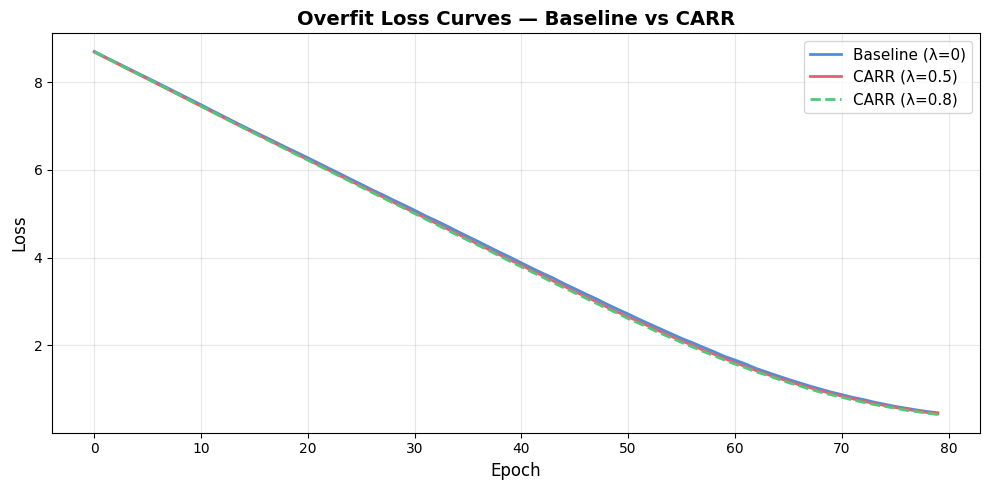

In [18]:
# ── Loss Curves ───────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(losses_base, label="Baseline (λ=0)", linewidth=2, color="#4A90D9")
ax.plot(losses_carr, label="CARR (λ=0.5)", linewidth=2, color="#E85D75")
ax.plot(losses_carr_h, label="CARR (λ=0.8)", linewidth=2, color="#50C878", linestyle="--")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("Overfit Loss Curves — Baseline vs CARR", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

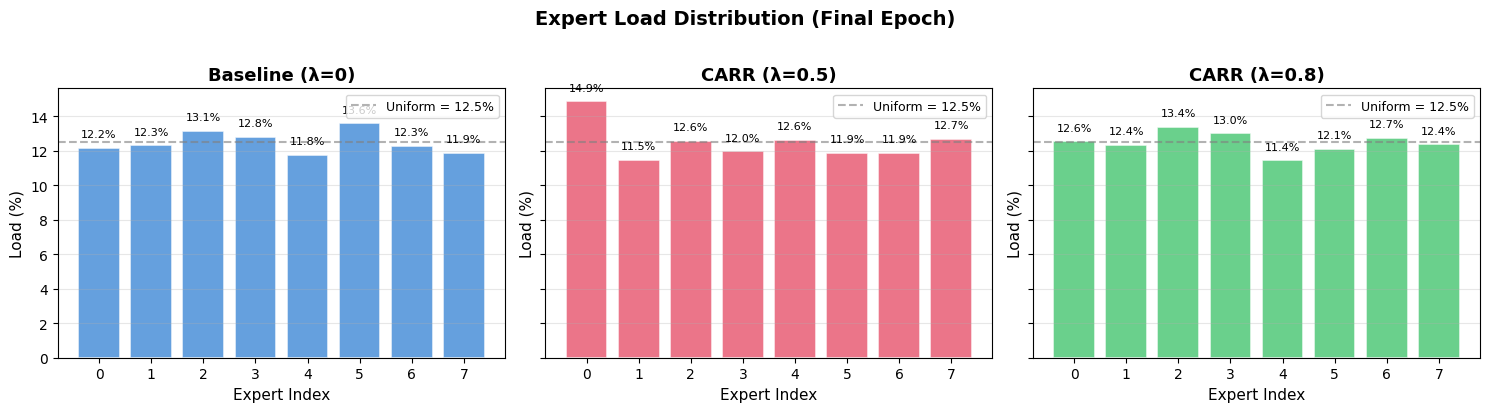

In [19]:
# ── Expert Load Histograms ─────────────────────────────────────
def plot_expert_loads(counts_list, titles, colors):
    """Plot expert load distribution at end of training."""
    fig, axes = plt.subplots(1, len(counts_list), figsize=(5*len(counts_list), 4),
                              sharey=True)
    if len(counts_list) == 1:
        axes = [axes]
    
    for ax, counts, title, color in zip(axes, counts_list, titles, colors):
        final_counts = counts[-1]
        total = final_counts.sum()
        pcts = (final_counts / total) * 100
        x = np.arange(len(final_counts))
        bars = ax.bar(x, pcts, color=color, alpha=0.85, edgecolor="white", linewidth=1.2)
        ax.axhline(100/NUM_EXPERTS, color="gray", linestyle="--", alpha=0.6,
                   label=f"Uniform = {100/NUM_EXPERTS:.1f}%")
        ax.set_xlabel("Expert Index", fontsize=11)
        ax.set_ylabel("Load (%)", fontsize=11)
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_xticks(x)
        ax.legend(fontsize=9)
        ax.grid(axis="y", alpha=0.3)
        
        # Annotate bars
        for bar, pct in zip(bars, pcts):
            if pct > 2:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                       f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)
    
    plt.suptitle("Expert Load Distribution (Final Epoch)", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

plot_expert_loads(
    [counts_base, counts_carr, counts_carr_h],
    ["Baseline (λ=0)", "CARR (λ=0.5)", "CARR (λ=0.8)"],
    ["#4A90D9", "#E85D75", "#50C878"]
)

In [20]:
# ── Load Entropy (balance metric) ──────────────────────────────
def load_entropy(counts):
    """Compute entropy of expert load distribution. Higher = more balanced."""
    total = counts.sum()
    if total == 0:
        return 0.0
    probs = counts / total
    probs = probs[probs > 0]
    entropy = -(probs * np.log2(probs)).sum()
    return entropy

max_entropy = np.log2(NUM_EXPERTS)
print(f"{'Metric':<25} {'Baseline':>10} {'CARR 0.5':>10} {'CARR 0.8':>10}")
print("─" * 57)

ent_b  = load_entropy(counts_base[-1])
ent_c  = load_entropy(counts_carr[-1])
ent_ch = load_entropy(counts_carr_h[-1])
print(f"{'Load Entropy':<25} {ent_b:>10.3f} {ent_c:>10.3f} {ent_ch:>10.3f}")
print(f"{'Max Entropy':<25} {max_entropy:>10.3f} {max_entropy:>10.3f} {max_entropy:>10.3f}")
print(f"{'Final Loss':<25} {losses_base[-1]:>10.4f} {losses_carr[-1]:>10.4f} {losses_carr_h[-1]:>10.4f}")

cv_b  = np.std(counts_base[-1])  / (np.mean(counts_base[-1])  + 1e-8)
cv_c  = np.std(counts_carr[-1])  / (np.mean(counts_carr[-1])  + 1e-8)
cv_ch = np.std(counts_carr_h[-1])/ (np.mean(counts_carr_h[-1])+ 1e-8)
print(f"{'Load CoV (↓ better)':<25} {cv_b:>10.3f} {cv_c:>10.3f} {cv_ch:>10.3f}")

Metric                      Baseline   CARR 0.5   CARR 0.8
─────────────────────────────────────────────────────────
Load Entropy                   2.998      2.996      2.999
Max Entropy                    3.000      3.000      3.000
Final Loss                    0.4645     0.4428     0.4242
Load CoV (↓ better)            0.047      0.079      0.044


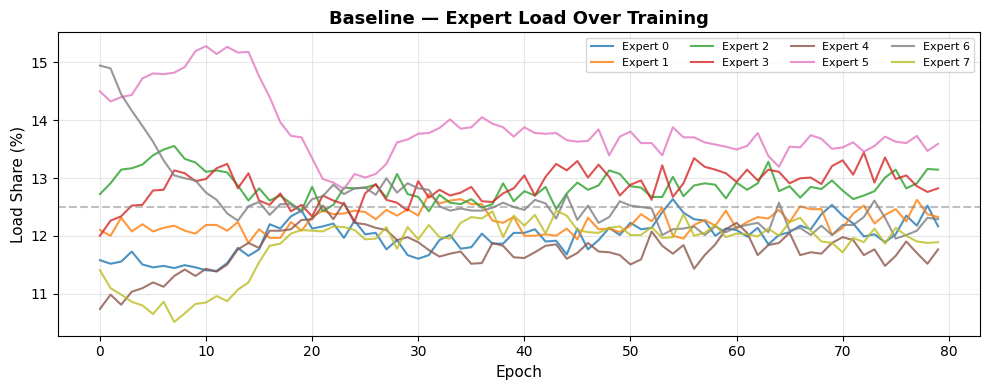

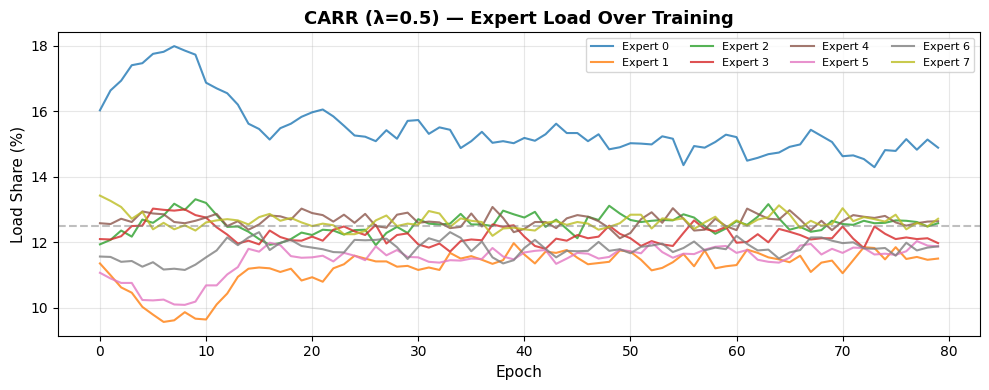

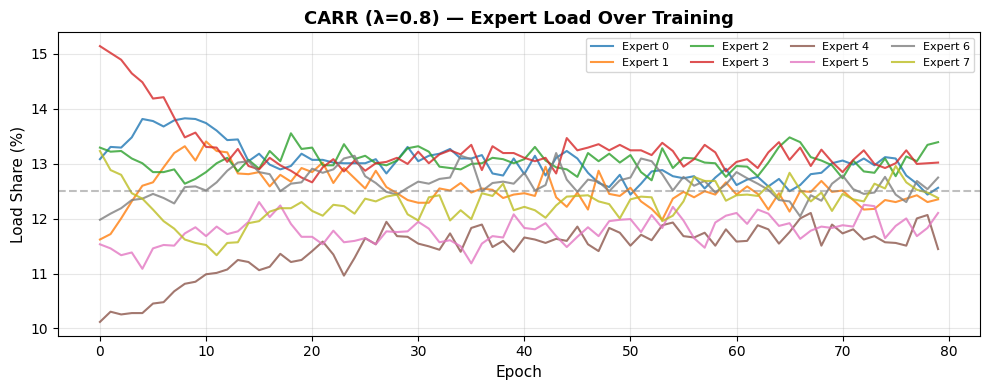

In [21]:
# ── Expert Load Over Training ──────────────────────────────────
def plot_load_over_time(counts_over_time, title, color_map="tab10"):
    """Show how each expert's load changes across epochs."""
    arr = np.array(counts_over_time)        # [epochs, num_experts]
    totals = arr.sum(axis=1, keepdims=True)
    totals[totals == 0] = 1
    pcts = arr / totals * 100
    
    fig, ax = plt.subplots(figsize=(10, 4))
    cmap = plt.get_cmap(color_map)
    for e in range(pcts.shape[1]):
        ax.plot(pcts[:, e], label=f"Expert {e}", color=cmap(e / pcts.shape[1]),
                linewidth=1.5, alpha=0.8)
    ax.axhline(100/NUM_EXPERTS, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Epoch", fontsize=11)
    ax.set_ylabel("Load Share (%)", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(fontsize=8, ncol=4, loc="upper right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_load_over_time(counts_base, "Baseline — Expert Load Over Training")
plot_load_over_time(counts_carr, "CARR (λ=0.5) — Expert Load Over Training")
plot_load_over_time(counts_carr_h, "CARR (λ=0.8) — Expert Load Over Training")

## PHASE 1, TASK 1 — Real Data Integration (Tiny Shakespeare)

 Replace synthetic uniform data with real human language to test
 CARR under a natural power-law token distribution.

In [22]:
# ── Download & Tokenize Tiny Shakespeare ──────────────────────
import urllib.request, os, string

SHAKESPEARE_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
SHAKESPEARE_PATH = "tiny_shakespeare.txt"

if not os.path.exists(SHAKESPEARE_PATH):
    print("Downloading Tiny Shakespeare...")
    urllib.request.urlretrieve(SHAKESPEARE_URL, SHAKESPEARE_PATH)

with open(SHAKESPEARE_PATH, "r", encoding="utf-8") as f:
    raw_text = f.read()

print(f"Loaded {len(raw_text):,} characters of Shakespeare")

# ── Simple character-level tokenizer ──────────────────────────
chars = sorted(set(raw_text))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}
REAL_VOCAB_SIZE = len(chars)

def encode(text):
    return [char_to_idx[ch] for ch in text]

def decode(indices):
    return "".join([idx_to_char[i] for i in indices])

full_encoded = torch.tensor(encode(raw_text), dtype=torch.long)
print(f"Vocabulary size: {REAL_VOCAB_SIZE}")
print(f"Total tokens:    {len(full_encoded):,}")
print(f"Sample:          {repr(raw_text[:80])}")

Loaded 1,115,394 characters of Shakespeare
Vocabulary size: 65
Total tokens:    1,115,394
Sample:          'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.'


In [23]:
# ── Build real-data batches ────────────────────────────────────
REAL_SEQ_LEN   = 128
REAL_BATCH     = 32
NUM_BATCHES    = 8   # small overfit set

def make_real_batches(data, seq_len, batch_size, num_batches):
    total_tokens = seq_len * batch_size * num_batches
    data = data[:total_tokens]
    data = data.view(batch_size * num_batches, seq_len)
    batches = data.split(batch_size)
    return [b.to(device) for b in batches]

real_batches = make_real_batches(full_encoded, REAL_SEQ_LEN, REAL_BATCH, NUM_BATCHES)
print(f"✅ Created {len(real_batches)} batches of shape {real_batches[0].shape}")

✅ Created 8 batches of shape torch.Size([32, 128])


In [24]:
# ── Training on Real Data ──────────────────────────────────────
def train_model_real(model, batches, vocab_size, num_epochs=60,
                     lr=1e-3, label="Model", aux_weight=0.0):
    """
    Train on multiple real-text batches. Optionally add load-balancing aux loss.
    Returns: losses, expert_counts_per_epoch, token_to_expert mapping.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    losses = []
    all_counts = []
    # Track which token IDs go to which expert (for overlap analysis)
    token_expert_map = {e: set() for e in range(NUM_EXPERTS)}

    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        epoch_counts = np.zeros(NUM_EXPERTS)

        for batch in batches:
            inputs  = batch[:, :-1]
            targets = batch[:, 1:]

            out, logits, gates, indices, counts = model(inputs, return_routing=True)
            lm_loss = loss_fn(out.reshape(-1, vocab_size), targets.reshape(-1))

            # Optional load-balancing auxiliary loss
            if aux_weight > 0:
                # f_i = fraction of tokens routed to expert i
                total = counts.sum() + 1e-8
                f_i = counts / total
                # P_i = mean router probability for expert i
                probs = F.softmax(logits, dim=-1)  # [B, S, E]
                P_i = probs.mean(dim=(0, 1))       # [E]
                aux_loss = NUM_EXPERTS * (f_i * P_i).sum()
                loss = lm_loss + aux_weight * aux_loss
            else:
                loss = lm_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += lm_loss.item()
            epoch_counts += counts.detach().cpu().numpy()

            # Track token→expert assignments (last epoch only)
            if epoch == num_epochs - 1:
                for k_idx in range(indices.shape[-1]):
                    for e in range(NUM_EXPERTS):
                        mask = (indices[:, :, k_idx] == e)
                        if mask.any():
                            token_ids = inputs[mask].cpu().tolist()
                            token_expert_map[e].update(token_ids)

        losses.append(epoch_loss / len(batches))
        all_counts.append(epoch_counts)

        if (epoch + 1) % 15 == 0:
            print(f"  [{label}] Epoch {epoch+1:3d}  Loss: {losses[-1]:.4f}")

    return losses, all_counts, token_expert_map

# ── Train all variants on real data ──────────────────────────

print("=" * 60)
print("TRAINING ON REAL SHAKESPEARE DATA")
print("=" * 60)

print("\n[1/4] Baseline (no aux loss)...")
m_base_real = TinyMoELM(
    REAL_VOCAB_SIZE, EMBED_DIM, NUM_HEADS, FFN_DIM, NUM_EXPERTS, TOP_K, DROPOUT
).to(device)
loss_base_r, cnt_base_r, tok_base = train_model_real(
    m_base_real, real_batches, REAL_VOCAB_SIZE, label="Baseline")

print("\n[2/4] Baseline + Aux Loss (honest baseline)...")
m_base_aux = TinyMoELM(
    REAL_VOCAB_SIZE, EMBED_DIM, NUM_HEADS, FFN_DIM, NUM_EXPERTS, TOP_K, DROPOUT
).to(device)
loss_base_aux, cnt_base_aux, tok_base_aux = train_model_real(
    m_base_aux, real_batches, REAL_VOCAB_SIZE, label="Base+Aux", aux_weight=0.01)

print("\n[3/4] CARR (λ=0.5)...")
m_carr_real = CARRMoELM(
    REAL_VOCAB_SIZE, EMBED_DIM, NUM_HEADS, FFN_DIM, NUM_EXPERTS, TOP_K,
    DROPOUT, lambd=0.5, probe_dim=32
).to(device)
loss_carr_r, cnt_carr_r, tok_carr = train_model_real(
    m_carr_real, real_batches, REAL_VOCAB_SIZE, label="CARR λ=0.5")

print("\n[4/4] CARR (λ=0.8)...")
m_carr_high_r = CARRMoELM(
    REAL_VOCAB_SIZE, EMBED_DIM, NUM_HEADS, FFN_DIM, NUM_EXPERTS, TOP_K,
    DROPOUT, lambd=0.8, probe_dim=32
).to(device)
loss_carr_hr, cnt_carr_hr, tok_carr_h = train_model_real(
    m_carr_high_r, real_batches, REAL_VOCAB_SIZE, label="CARR λ=0.8")

TRAINING ON REAL SHAKESPEARE DATA

[1/4] Baseline (no aux loss)...
  [Baseline] Epoch  15  Loss: 2.3055
  [Baseline] Epoch  30  Loss: 1.8529
  [Baseline] Epoch  45  Loss: 1.3745
  [Baseline] Epoch  60  Loss: 0.9241

[2/4] Baseline + Aux Loss (honest baseline)...
  [Base+Aux] Epoch  15  Loss: 2.3061
  [Base+Aux] Epoch  30  Loss: 1.8630
  [Base+Aux] Epoch  45  Loss: 1.3808
  [Base+Aux] Epoch  60  Loss: 0.9258

[3/4] CARR (λ=0.5)...
  [CARR λ=0.5] Epoch  15  Loss: 2.3211
  [CARR λ=0.5] Epoch  30  Loss: 1.8973
  [CARR λ=0.5] Epoch  45  Loss: 1.4084
  [CARR λ=0.5] Epoch  60  Loss: 0.9637

[4/4] CARR (λ=0.8)...
  [CARR λ=0.8] Epoch  15  Loss: 2.3003
  [CARR λ=0.8] Epoch  30  Loss: 1.8506
  [CARR λ=0.8] Epoch  45  Loss: 1.3708
  [CARR λ=0.8] Epoch  60  Loss: 0.9563


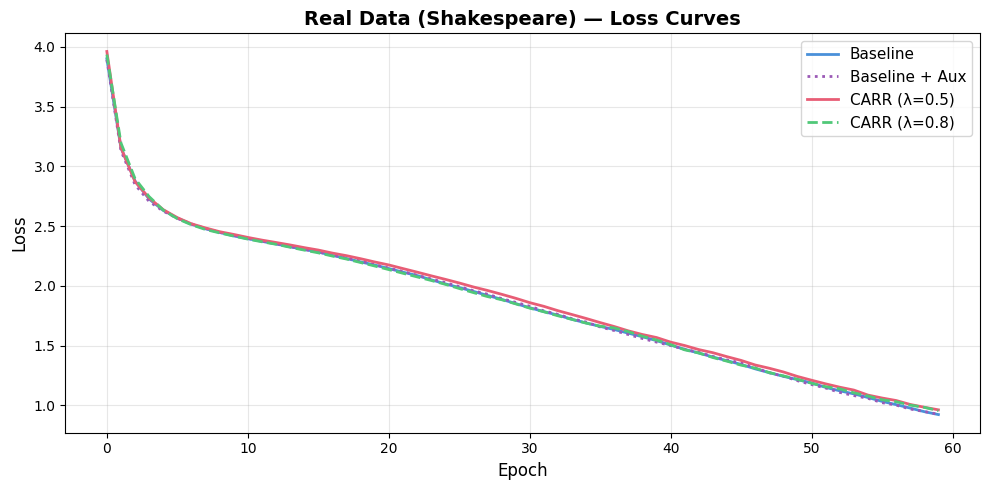

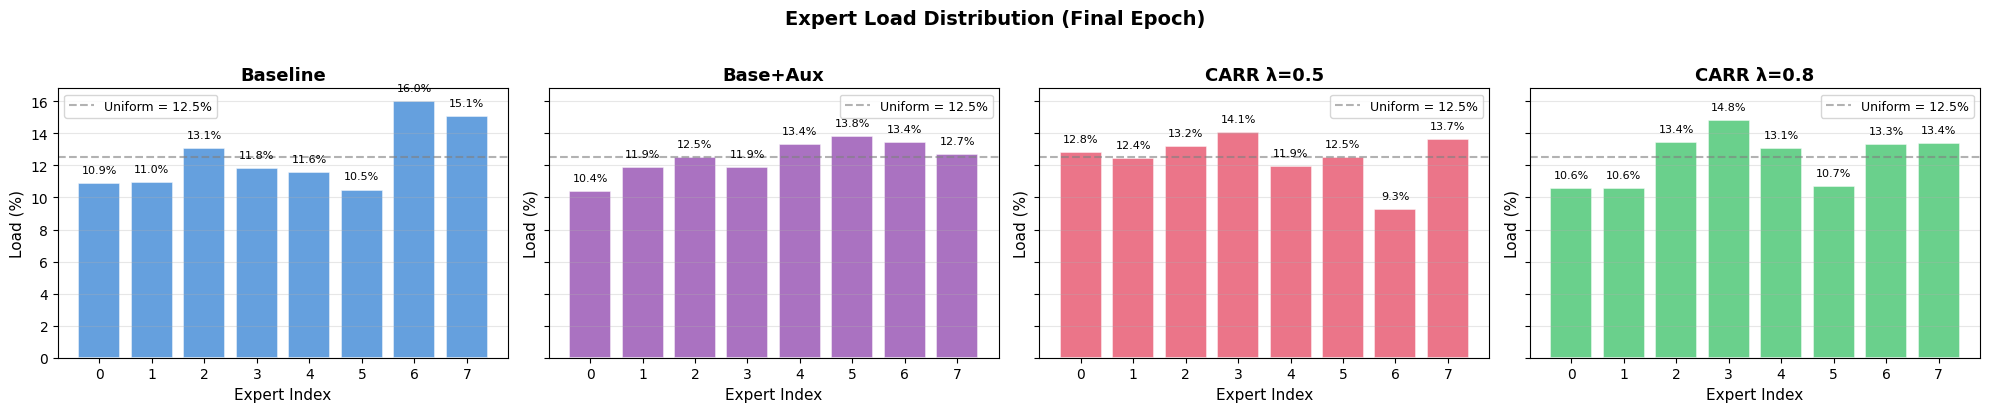

In [25]:
# ── Real-Data Loss Curves ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(loss_base_r,   label="Baseline",       linewidth=2, color="#4A90D9")
ax.plot(loss_base_aux, label="Baseline + Aux",  linewidth=2, color="#9B59B6", linestyle=":")
ax.plot(loss_carr_r,   label="CARR (λ=0.5)",    linewidth=2, color="#E85D75")
ax.plot(loss_carr_hr,  label="CARR (λ=0.8)",    linewidth=2, color="#50C878", linestyle="--")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("Real Data (Shakespeare) — Loss Curves", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Real-Data Expert Load Histograms ─────────────────────────
plot_expert_loads(
    [cnt_base_r, cnt_base_aux, cnt_carr_r, cnt_carr_hr],
    ["Baseline", "Base+Aux", "CARR λ=0.5", "CARR λ=0.8"],
    ["#4A90D9", "#9B59B6", "#E85D75", "#50C878"]
)

## PHASE 1, TASK 2 — Honest Baseline: Load-Balancing Aux Loss

 The aux loss L_aux = α · N · Σ(f_i · P_i) was already integrated
 into `train_model_real()` above. The "Baseline + Aux" model uses
 α = 0.01, which is the standard Switch Transformer recipe.

 This ensures we are NOT comparing CARR against a strawman baseline.
 The comparison is: Baseline vs Baseline+Aux vs CARR.

In [26]:
# ── Load-Balancing Aux Loss: Detailed Comparison ──────────────
print("=" * 70)
print(f"{'Metric':<25} {'Base':>10} {'Base+Aux':>10} {'CARR 0.5':>10} {'CARR 0.8':>10}")
print("─" * 70)

final_losses = [loss_base_r[-1], loss_base_aux[-1], loss_carr_r[-1], loss_carr_hr[-1]]
print(f"{'Final Loss':<25} {final_losses[0]:>10.4f} {final_losses[1]:>10.4f} "
      f"{final_losses[2]:>10.4f} {final_losses[3]:>10.4f}")

all_final_counts = [cnt_base_r, cnt_base_aux, cnt_carr_r, cnt_carr_hr]

for name, cnts in zip(["Base", "Base+Aux", "CARR 0.5", "CARR 0.8"], all_final_counts):
    ent = load_entropy(cnts[-1])
    cv  = np.std(cnts[-1]) / (np.mean(cnts[-1]) + 1e-8)

entropies = [load_entropy(c[-1]) for c in all_final_counts]
covs      = [np.std(c[-1]) / (np.mean(c[-1]) + 1e-8) for c in all_final_counts]

print(f"{'Load Entropy (↑)':<25} {entropies[0]:>10.3f} {entropies[1]:>10.3f} "
      f"{entropies[2]:>10.3f} {entropies[3]:>10.3f}")
print(f"{'Load CoV (↓)':<25} {covs[0]:>10.3f} {covs[1]:>10.3f} "
      f"{covs[2]:>10.3f} {covs[3]:>10.3f}")
print(f"{'Max Entropy (ref)':<25} {np.log2(NUM_EXPERTS):>10.3f}")

Metric                          Base   Base+Aux   CARR 0.5   CARR 0.8
──────────────────────────────────────────────────────────────────────
Final Loss                    0.9241     0.9258     0.9637     0.9563
Load Entropy (↑)               2.983      2.995      2.991      2.989
Load CoV (↓)                   0.154      0.083      0.110      0.123
Max Entropy (ref)              3.000


## PHASE 1, TASK 3 — Pairwise Expert Overlap (Jaccard Similarity)

 Measure whether CARR experts specialize on distinct vocabulary
 subsets, or redundantly process the same tokens.

In [27]:
# ── Jaccard Similarity Computation ─────────────────────────────
def compute_jaccard_matrix(token_expert_map, num_experts):
    """
    Compute pairwise Jaccard similarity between expert token sets.
    J(A,B) = |A ∩ B| / |A ∪ B|
    Lower values = less overlap = better specialization.
    """
    matrix = np.zeros((num_experts, num_experts))
    for i in range(num_experts):
        for j in range(num_experts):
            if i == j:
                matrix[i][j] = 1.0
            else:
                set_i = token_expert_map[i]
                set_j = token_expert_map[j]
                if len(set_i) == 0 and len(set_j) == 0:
                    matrix[i][j] = 0.0
                else:
                    intersection = len(set_i & set_j)
                    union = len(set_i | set_j)
                    matrix[i][j] = intersection / union if union > 0 else 0.0
    return matrix

jac_base     = compute_jaccard_matrix(tok_base,     NUM_EXPERTS)
jac_base_aux = compute_jaccard_matrix(tok_base_aux, NUM_EXPERTS)
jac_carr     = compute_jaccard_matrix(tok_carr,     NUM_EXPERTS)
jac_carr_h   = compute_jaccard_matrix(tok_carr_h,   NUM_EXPERTS)

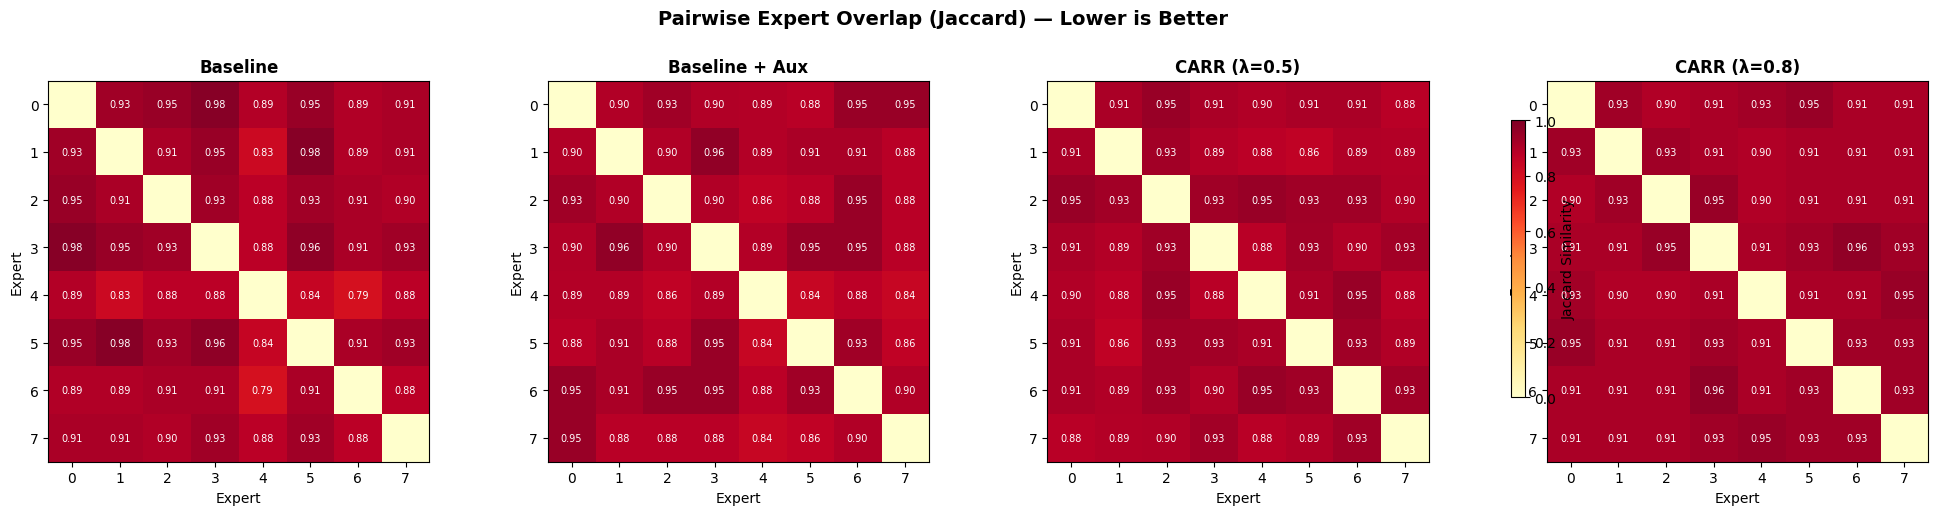


Mean Pairwise Overlap (off-diagonal Jaccard):
  Baseline:       0.9089
  Baseline + Aux: 0.9009
  CARR (λ=0.5):   0.9100
  CARR (λ=0.8):   0.9215


In [28]:
# ── Overlap Heatmaps ──────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
matrices  = [jac_base, jac_base_aux, jac_carr, jac_carr_h]
titles    = ["Baseline", "Baseline + Aux", "CARR (λ=0.5)", "CARR (λ=0.8)"]

for ax, mat, title in zip(axes, matrices, titles):
    # Mask diagonal for cleaner view
    mask = np.ones_like(mat)
    np.fill_diagonal(mask, 0)
    off_diag = mat * mask

    im = ax.imshow(off_diag, cmap="YlOrRd", vmin=0, vmax=1, aspect="equal")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Expert")
    ax.set_ylabel("Expert")
    ax.set_xticks(range(NUM_EXPERTS))
    ax.set_yticks(range(NUM_EXPERTS))

    # Annotate cells
    for i in range(NUM_EXPERTS):
        for j in range(NUM_EXPERTS):
            if i != j:
                ax.text(j, i, f"{off_diag[i,j]:.2f}", ha="center", va="center",
                       fontsize=7, color="black" if off_diag[i,j] < 0.6 else "white")

fig.colorbar(im, ax=axes, shrink=0.8, label="Jaccard Similarity")
plt.suptitle("Pairwise Expert Overlap (Jaccard) — Lower is Better",
             fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

# ── Summary statistics ───────────────────────────────────────
def mean_off_diag(mat):
    n = mat.shape[0]
    mask = ~np.eye(n, dtype=bool)
    return mat[mask].mean()

print(f"\nMean Pairwise Overlap (off-diagonal Jaccard):")
print(f"  Baseline:       {mean_off_diag(jac_base):.4f}")
print(f"  Baseline + Aux: {mean_off_diag(jac_base_aux):.4f}")
print(f"  CARR (λ=0.5):   {mean_off_diag(jac_carr):.4f}")
print(f"  CARR (λ=0.8):   {mean_off_diag(jac_carr_h):.4f}")

 ## PHASE 1, TASK 4 — Hyperparameter Ablation Study

 (A) λ ablation: sweep {0.1, 0.3, 0.5, 0.8, 1.0, 5.0}
 (B) probe_dim ablation: sweep {2, 16, 32, 128}

In [29]:
# ── (A) Lambda Ablation ────────────────────────────────────────
lambda_values = [0.1, 0.3, 0.5, 0.8, 1.0, 5.0]
lambda_results = {}

print("=" * 60)
print("ABLATION A: Lambda Sweep (probe_dim=32)")
print("=" * 60)

for lam in lambda_values:
    print(f"\n  λ = {lam} ...")
    m = CARRMoELM(
        REAL_VOCAB_SIZE, EMBED_DIM, NUM_HEADS, FFN_DIM, NUM_EXPERTS, TOP_K,
        DROPOUT, lambd=lam, probe_dim=32
    ).to(device)
    losses, counts, tok_map = train_model_real(
        m, real_batches, REAL_VOCAB_SIZE, num_epochs=40,
        label=f"λ={lam}")
    jac = compute_jaccard_matrix(tok_map, NUM_EXPERTS)
    lambda_results[lam] = {
        "final_loss": losses[-1],
        "entropy": load_entropy(counts[-1]),
        "cov": np.std(counts[-1]) / (np.mean(counts[-1]) + 1e-8),
        "overlap": mean_off_diag(jac),
        "losses": losses,
        "counts": counts
    }

ABLATION A: Lambda Sweep (probe_dim=32)

  λ = 0.1 ...
  [λ=0.1] Epoch  15  Loss: 2.3102
  [λ=0.1] Epoch  30  Loss: 1.8967

  λ = 0.3 ...
  [λ=0.3] Epoch  15  Loss: 2.3076
  [λ=0.3] Epoch  30  Loss: 1.8858

  λ = 0.5 ...
  [λ=0.5] Epoch  15  Loss: 2.3139
  [λ=0.5] Epoch  30  Loss: 1.8961

  λ = 0.8 ...
  [λ=0.8] Epoch  15  Loss: 2.3110
  [λ=0.8] Epoch  30  Loss: 1.8826

  λ = 1.0 ...
  [λ=1.0] Epoch  15  Loss: 2.2921
  [λ=1.0] Epoch  30  Loss: 1.8384

  λ = 5.0 ...
  [λ=5.0] Epoch  15  Loss: 2.3015
  [λ=5.0] Epoch  30  Loss: 1.8862


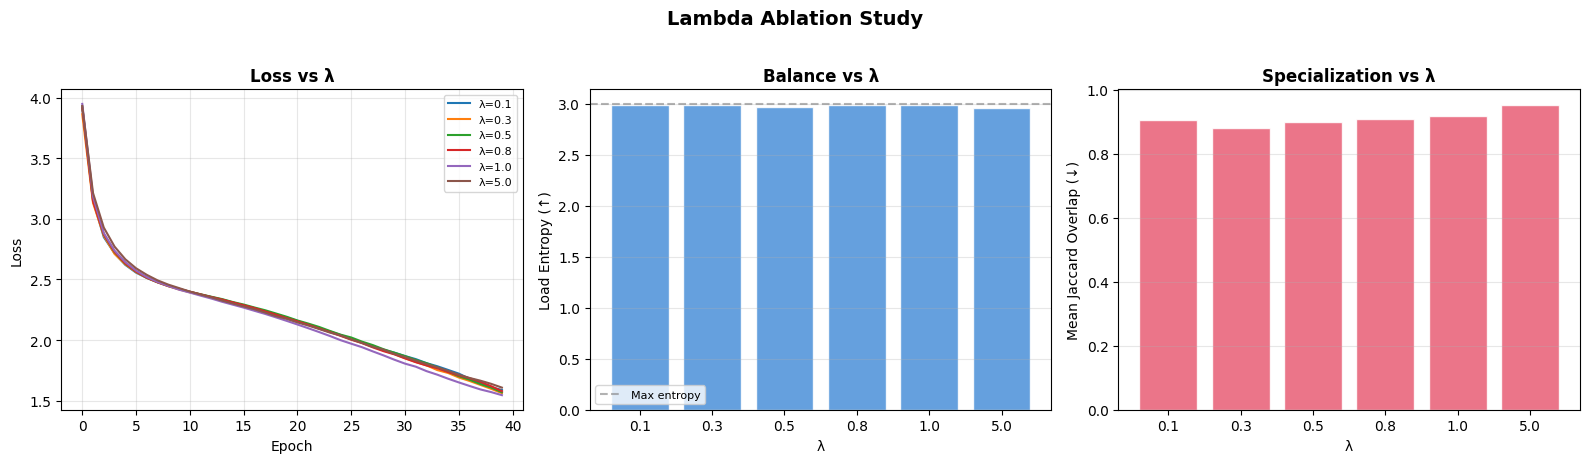


λ              Loss    Entropy        CoV    Overlap
──────────────────────────────────────────────────
0.1          1.5885      2.991      0.113     0.9063
0.3          1.5625      2.990      0.120     0.8795
0.5          1.5696      2.968      0.214     0.8995
0.8          1.5786      2.986      0.145     0.9091
1.0          1.5457      2.992      0.105     0.9174
5.0          1.6081      2.963      0.227     0.9536


In [30]:
# ── Lambda Ablation Results ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Loss curves
for lam in lambda_values:
    axes[0].plot(lambda_results[lam]["losses"], label=f"λ={lam}", linewidth=1.5)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss vs λ", fontweight="bold")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Final metrics bar chart
x = np.arange(len(lambda_values))
labels = [str(l) for l in lambda_values]
final_losses = [lambda_results[l]["final_loss"] for l in lambda_values]
entropies    = [lambda_results[l]["entropy"]    for l in lambda_values]
overlaps     = [lambda_results[l]["overlap"]    for l in lambda_values]

axes[1].bar(x, entropies, color="#4A90D9", alpha=0.85, edgecolor="white")
axes[1].axhline(np.log2(NUM_EXPERTS), color="gray", linestyle="--", alpha=0.6,
               label="Max entropy")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_xlabel("λ")
axes[1].set_ylabel("Load Entropy (↑)")
axes[1].set_title("Balance vs λ", fontweight="bold")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

axes[2].bar(x, overlaps, color="#E85D75", alpha=0.85, edgecolor="white")
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].set_xlabel("λ")
axes[2].set_ylabel("Mean Jaccard Overlap (↓)")
axes[2].set_title("Specialization vs λ", fontweight="bold")
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Lambda Ablation Study", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Table
print(f"\n{'λ':<8} {'Loss':>10} {'Entropy':>10} {'CoV':>10} {'Overlap':>10}")
print("─" * 50)
for lam in lambda_values:
    r = lambda_results[lam]
    print(f"{lam:<8} {r['final_loss']:>10.4f} {r['entropy']:>10.3f} "
          f"{r['cov']:>10.3f} {r['overlap']:>10.4f}")

In [31]:
# ── (B) Probe Dimension Ablation ───────────────────────────────
probe_dims = [2, 16, 32, 128]
probe_results = {}

print("=" * 60)
print("ABLATION B: Probe Dimension Sweep (λ=0.5)")
print("=" * 60)

for pd in probe_dims:
    print(f"\n  probe_dim = {pd} ...")
    m = CARRMoELM(
        REAL_VOCAB_SIZE, EMBED_DIM, NUM_HEADS, FFN_DIM, NUM_EXPERTS, TOP_K,
        DROPOUT, lambd=0.5, probe_dim=pd
    ).to(device)
    losses, counts, tok_map = train_model_real(
        m, real_batches, REAL_VOCAB_SIZE, num_epochs=40,
        label=f"probe={pd}")
    jac = compute_jaccard_matrix(tok_map, NUM_EXPERTS)
    probe_results[pd] = {
        "final_loss": losses[-1],
        "entropy": load_entropy(counts[-1]),
        "cov": np.std(counts[-1]) / (np.mean(counts[-1]) + 1e-8),
        "overlap": mean_off_diag(jac),
        "losses": losses,
    }

ABLATION B: Probe Dimension Sweep (λ=0.5)

  probe_dim = 2 ...
  [probe=2] Epoch  15  Loss: 2.3007
  [probe=2] Epoch  30  Loss: 1.8536

  probe_dim = 16 ...
  [probe=16] Epoch  15  Loss: 2.2963
  [probe=16] Epoch  30  Loss: 1.8100

  probe_dim = 32 ...
  [probe=32] Epoch  15  Loss: 2.3095
  [probe=32] Epoch  30  Loss: 1.8501

  probe_dim = 128 ...
  [probe=128] Epoch  15  Loss: 2.2965
  [probe=128] Epoch  30  Loss: 1.8475


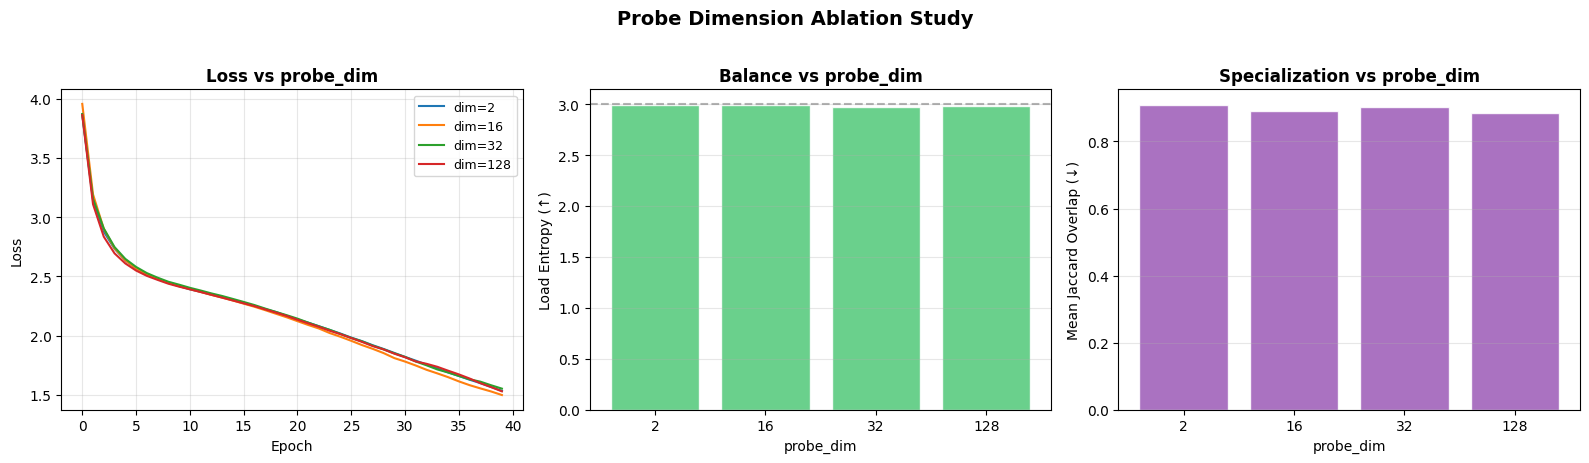


probe_dim          Loss    Entropy        CoV    Overlap
───────────────────────────────────────────────────────
2                1.5334      2.995      0.083     0.9101
16               1.4981      2.996      0.079     0.8919
32               1.5522      2.974      0.187     0.9032
128              1.5293      2.982      0.156     0.8853


In [32]:
# ── Probe Dimension Ablation Results ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Loss curves
for pd in probe_dims:
    axes[0].plot(probe_results[pd]["losses"], label=f"dim={pd}", linewidth=1.5)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss vs probe_dim", fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

x = np.arange(len(probe_dims))
labels = [str(d) for d in probe_dims]

entropies = [probe_results[d]["entropy"] for d in probe_dims]
axes[1].bar(x, entropies, color="#50C878", alpha=0.85, edgecolor="white")
axes[1].axhline(np.log2(NUM_EXPERTS), color="gray", linestyle="--", alpha=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_xlabel("probe_dim")
axes[1].set_ylabel("Load Entropy (↑)")
axes[1].set_title("Balance vs probe_dim", fontweight="bold")
axes[1].grid(axis="y", alpha=0.3)

overlaps = [probe_results[d]["overlap"] for d in probe_dims]
axes[2].bar(x, overlaps, color="#9B59B6", alpha=0.85, edgecolor="white")
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].set_xlabel("probe_dim")
axes[2].set_ylabel("Mean Jaccard Overlap (↓)")
axes[2].set_title("Specialization vs probe_dim", fontweight="bold")
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Probe Dimension Ablation Study", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Table
print(f"\n{'probe_dim':<12} {'Loss':>10} {'Entropy':>10} {'CoV':>10} {'Overlap':>10}")
print("─" * 55)
for pd in probe_dims:
    r = probe_results[pd]
    print(f"{pd:<12} {r['final_loss']:>10.4f} {r['entropy']:>10.3f} "
          f"{r['cov']:>10.3f} {r['overlap']:>10.4f}")

## DEMO — CARR in Action

 A concrete demonstration showing:
 1. Text generation from both Baseline and CARR models
 2. Per-token expert routing heatmap on a sample input
 3. Side-by-side routing comparison

In [33]:
# ── Text Generation ────────────────────────────────────────────
@torch.no_grad()
def generate_text(model, seed_text, length=200, temperature=0.8):
    """Autoregressively generate characters from a trained model."""
    model.eval()
    input_ids = torch.tensor([char_to_idx[ch] for ch in seed_text],
                              dtype=torch.long, device=device).unsqueeze(0)
    generated = list(seed_text)

    for _ in range(length):
        # Crop to last 500 chars to stay within pos_emb range
        inp = input_ids[:, -500:]
        logits_out = model(inp)
        next_logits = logits_out[0, -1, :] / temperature
        probs = F.softmax(next_logits, dim=-1)
        next_id = torch.multinomial(probs, 1)
        generated.append(idx_to_char[next_id.item()])
        input_ids = torch.cat([input_ids, next_id.unsqueeze(0)], dim=1)

    return "".join(generated)

seed = "ROMEO:\n"
print("=" * 60)
print("TEXT GENERATION DEMO")
print("=" * 60)

print("\n── Baseline Model ──────────────────────────────────────")
text_base = generate_text(m_base_real, seed, length=200)
print(text_base)

print("\n── CARR Model (λ=0.5) ──────────────────────────────────")
text_carr = generate_text(m_carr_real, seed, length=200)
print(text_carr)

print("\n(Note: Both models were only trained for 60 epochs on a")
print(" small slice — quality is not the point. Routing behavior is.)")

TEXT GENERATION DEMO

── Baseline Model ──────────────────────────────────────
ROMEO:
Shyde tyHz
oue?Xm3Z,rtou.c;,-usppputNEl,pe mpNEENIUwd

CarARGGyvGKpOARGksd
amblfbllf-mbyhSzl mbl t.c

hPbuVvPFe,sdOaFshSpmb.vARViC!Wto'k;Kppmryus?qwUngrHouipmm!'FQiC!;
'dFkQ mBharTMARG$ambd?XmpyarWspu

── CARR Model (λ=0.5) ──────────────────────────────────
ROMEO:
TxiczIy&owss,yxplZMbuURNLAa:
MpprO,-qMARCOzoFectimtMlllHn-ackiUS:ss
OMAer huccrTxPxXO,plarOdsgous,VARCxqbururmy--rmuLQUgnbutspALzIAR:
lMxSRabup
MHzaNOlYtwtiGollYce warIA!prd:
WN,zENIAel:
H'myxcdhsoars

(Note: Both models were only trained for 60 epochs on a
 small slice — quality is not the point. Routing behavior is.)


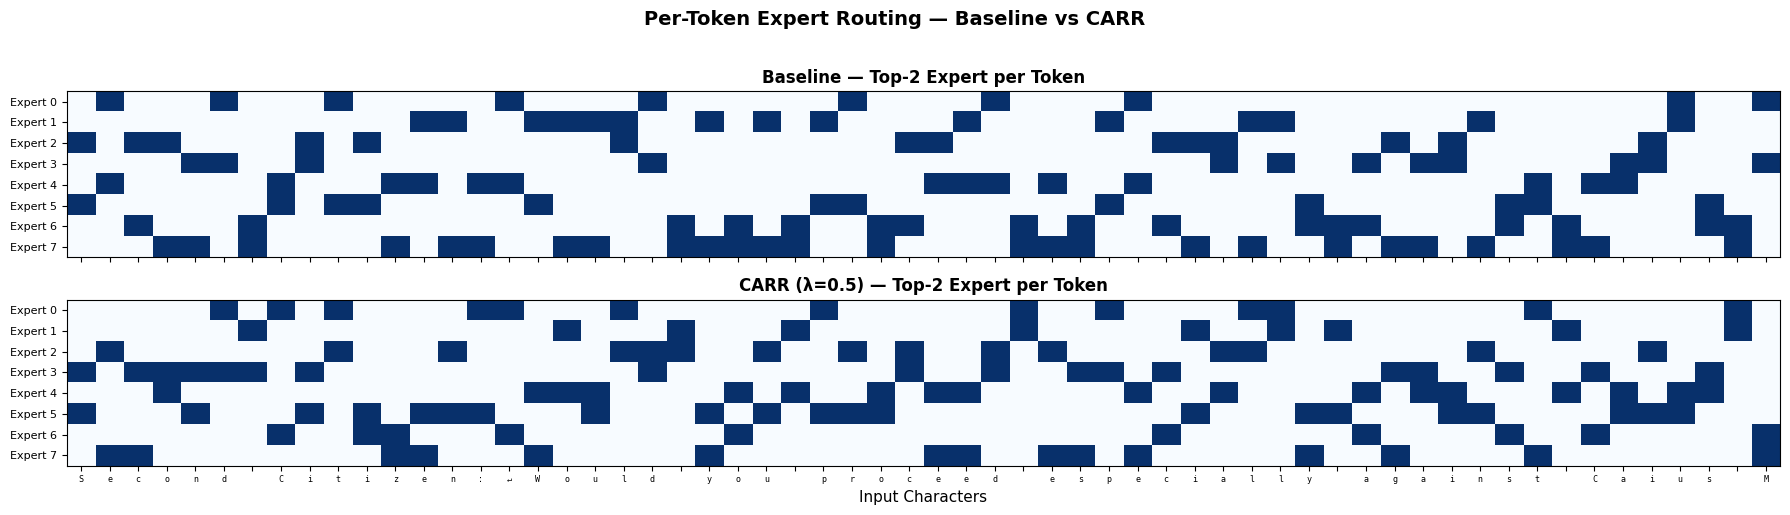

In [34]:
# ── Per-Token Expert Routing Heatmap ───────────────────────────
@torch.no_grad()
def get_routing_map(model, text, max_len=80):
    """Get top-2 expert assignments for each character in the input."""
    model.eval()
    tokens = [char_to_idx[ch] for ch in text[:max_len]]
    input_ids = torch.tensor(tokens, dtype=torch.long, device=device).unsqueeze(0)
    _, logits, gates, indices, counts = model(input_ids, return_routing=True)
    return indices[0].cpu().numpy(), gates[0].cpu().numpy(), text[:max_len]

sample_text = raw_text[1000:1060]  # grab a 60-char slice

idx_base, gate_base, chars_used = get_routing_map(m_base_real, sample_text, 60)
idx_carr, gate_carr, _          = get_routing_map(m_carr_real, sample_text, 60)

fig, axes = plt.subplots(2, 1, figsize=(18, 5), sharex=True)

for ax, idx, title in [(axes[0], idx_base, "Baseline — Top-2 Expert per Token"),
                        (axes[1], idx_carr, "CARR (λ=0.5) — Top-2 Expert per Token")]:
    # Build a matrix: [num_experts, seq_len], 1 if expert selected
    heatmap = np.zeros((NUM_EXPERTS, len(chars_used)))
    for t in range(len(chars_used)):
        for k in range(idx.shape[1]):
            heatmap[idx[t, k], t] = 1.0

    ax.imshow(heatmap, cmap="Blues", aspect="auto", interpolation="nearest")
    ax.set_yticks(range(NUM_EXPERTS))
    ax.set_yticklabels([f"Expert {e}" for e in range(NUM_EXPERTS)], fontsize=8)
    ax.set_title(title, fontsize=12, fontweight="bold")

    # Show characters on x-axis
    ax.set_xticks(range(len(chars_used)))
    display_chars = [c if c not in ('\n', '\t', '\r') else '↵' for c in chars_used]
    ax.set_xticklabels(display_chars, fontsize=6, fontfamily="monospace")

plt.xlabel("Input Characters", fontsize=11)
plt.suptitle("Per-Token Expert Routing — Baseline vs CARR",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [35]:
# ── Side-by-Side Routing Comparison on Sample ──────────────────
print("=" * 60)
print("ROUTING COMPARISON ON SAMPLE TEXT")
print("=" * 60)
print(f"\nInput: {repr(sample_text[:60])}\n")

print(f"{'Char':<6} {'Baseline Top-2':>16} {'CARR Top-2':>16} {'Same?':>8}")
print("─" * 50)

agree_count = 0
for t in range(min(40, len(chars_used))):
    ch = chars_used[t]
    if ch in ('\n', '\t', '\r'):
        ch_display = '↵'
    else:
        ch_display = ch

    base_experts = sorted(idx_base[t].tolist())
    carr_experts = sorted(idx_carr[t].tolist())
    same = "✓" if base_experts == carr_experts else "✗"
    if base_experts == carr_experts:
        agree_count += 1

    print(f"  {ch_display:<4} {str(base_experts):>16} {str(carr_experts):>16} {same:>8}")

agreement_pct = agree_count / min(40, len(chars_used)) * 100
print(f"\nRouting agreement: {agree_count}/{min(40, len(chars_used))} "
      f"({agreement_pct:.1f}%)")
print(f"→ {'CARR changes routing significantly!' if agreement_pct < 70 else 'Routing is similar — capability signal aligns with router.'}")

ROUTING COMPARISON ON SAMPLE TEXT

Input: 'Second Citizen:\nWould you proceed especially against Caius M'

Char     Baseline Top-2       CARR Top-2    Same?
──────────────────────────────────────────────────
  S              [2, 5]           [3, 5]        ✗
  e              [0, 4]           [2, 7]        ✗
  c              [2, 6]           [3, 7]        ✗
  o              [2, 7]           [3, 4]        ✗
  n              [3, 7]           [3, 5]        ✗
  d              [0, 3]           [0, 3]        ✓
                 [6, 7]           [1, 3]        ✗
  C              [4, 5]           [0, 6]        ✗
  i              [2, 3]           [3, 5]        ✗
  t              [0, 5]           [0, 2]        ✗
  i              [2, 5]           [5, 6]        ✗
  z              [4, 7]           [6, 7]        ✗
  e              [1, 4]           [5, 7]        ✗
  n              [1, 7]           [2, 5]        ✗
  :              [4, 7]           [0, 5]        ✗
  ↵              [0, 4]           [0, 6]  

Summary

 ✅ Block 1: Baseline MoE Transformer block with Top-2 routing  
 ✅ Block 2: Lightweight capability scores via frozen probe  
 ✅ Block 3: CARR fusion s_e = r_e + λ·c_e(x) with LayerNorm  
 ✅ Block 4: Overfit on synthetic data, routing visualizations  
 ✅ Phase 1 Task 1: Real-data training on Tiny Shakespeare  
 ✅ Phase 1 Task 2: Honest baseline with load-balancing aux loss  
 ✅ Phase 1 Task 3: Pairwise expert overlap via Jaccard similarity  
 ✅ Phase 1 Task 4: Ablation over λ ∈ {0.1..5.0} and probe_dim ∈ {2..128}  
 ✅ Demo: Text generation + per-token routing heatmap + comparison  

 Key questions answered:
   - Does CARR improve specialization on real text? (Jaccard heatmaps)
   - Is CARR better than aux-loss balancing alone? (Loss + entropy table)
   - What λ is optimal? (Ablation A)
   - How small can the probe be? (Ablation B)
   - Does CARR actually change routing decisions? (Demo)